# CPEN run-result plots

Reusable plotting utilities for scientific comparison of sweep results stored as Parquet files.

The main function, `plot_eta_sweep`, accepts either a filename run tag, a metadata configuration, or both. It reduces each run to its best epoch-level metrics and displays one row of panels:

1. minimum training loss
2. maximum validation accuracy
3. maximum validation ROC AUC
4. one background-rejection panel for each recorded signal efficiency

Depth determines color. Width is retained in the legend so distinct architectures are not silently merged. The η₀ axis is logarithmic.

In [6]:
from __future__ import annotations

from collections.abc import Mapping, Sequence
from pathlib import Path
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULT_ROOT = Path(
    "/scratch/gpfs/BHANIN/jdezoort/cpen_runs/toptagging_output/adamw/sweep_lr"
)

# A clean scientific style that remains readable in papers and presentations.
mpl.rcParams.update(
    {
        "figure.dpi": 130,
        "savefig.dpi": 300,
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "semibold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.alpha": 0.20,
        "grid.linewidth": 0.7,
        "legend.frameon": False,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
    }
)

In [7]:
_REJECTION_RE = re.compile(r"^val_bg_rejection(?:_(\d+)p(\d+))?$")


def _matches(value, target) -> bool:
    """Compare metadata robustly across NumPy, Python, and nullable values."""
    if callable(target):
        return bool(target(value))
    if isinstance(target, (set, tuple, list, frozenset)):
        return any(_matches(value, item) for item in target)
    if isinstance(value, (float, np.floating)) and isinstance(target, (float, int)):
        return bool(np.isclose(value, target, rtol=1e-9, atol=1e-12))
    if pd.isna(value):
        return pd.isna(target)
    return value == target


def _signal_efficiency(metric: str) -> float:
    """Decode val_bg_rejection[_0p3] into its signal efficiency."""
    match = _REJECTION_RE.match(metric)
    if match is None:
        raise ValueError(f"Not a background-rejection metric: {metric}")
    if match.group(1) is None:
        return 0.5  # historical unsuffixed metric is rejection at eps_S = 0.5
    return float(f"{match.group(1)}.{match.group(2)}")


def find_runs(
    result_root: str | Path = RESULT_ROOT,
    *,
    run_tag: str | Sequence[str] | None = None,
    config: Mapping[str, object] | None = None,
) -> list[tuple[Path, pd.DataFrame]]:
    """Load Parquet runs matching filename tokens and/or metadata values.

    `run_tag` may be one token or a sequence of tokens; every token must occur
    in the filename. `config` values may be scalars, collections, or callables.
    """
    root = Path(result_root).expanduser()
    tags = [] if run_tag is None else ([run_tag] if isinstance(run_tag, str) else list(run_tag))
    matches: list[tuple[Path, pd.DataFrame]] = []

    for path in sorted(root.glob("*.parquet")):
        if not all(tag in path.stem for tag in tags):
            continue
        frame = pd.read_parquet(path)
        if frame.empty:
            continue
        metadata = frame.iloc[0]
        if config and any(
            key not in frame.columns or not _matches(metadata[key], target)
            for key, target in config.items()
        ):
            continue
        matches.append((path, frame))

    if not matches:
        details = f"run_tag={run_tag!r}, config={dict(config or {})!r}"
        raise FileNotFoundError(f"No Parquet runs matched {details} under {root}")
    return matches


def summarize_runs(
    runs: Sequence[tuple[Path, pd.DataFrame]],
) -> tuple[pd.DataFrame, list[str]]:
    """Reduce each run to minimum train loss and maximum validation metrics."""
    rejection_metrics = sorted(
        {
            column
            for _, frame in runs
            for column in frame.columns
            if _REJECTION_RE.match(column) and frame[column].notna().any()
        },
        key=_signal_efficiency,
        reverse=True,
    )
    metrics = ["train_loss", "val_acc", "val_roc_auc", *rejection_metrics]
    rows: list[dict[str, object]] = []

    for path, frame in runs:
        epoch_rows = frame.loc[frame.get("record_type", "epoch") == "epoch"]
        if epoch_rows.empty:
            epoch_rows = frame
        row: dict[str, object] = {
            "path": path,
            "run": path.stem,
            "depth": int(frame["depth"].iloc[0]),
            "width": int(frame["width"].iloc[0]),
            "eta_0": float(frame["eta_0"].iloc[0]),
            "epochs_completed": int(epoch_rows["epoch"].max()) + 1,
        }
        for metric in metrics:
            values = epoch_rows[metric].dropna() if metric in epoch_rows else pd.Series(dtype=float)
            row[metric] = (
                values.min() if metric == "train_loss" and not values.empty
                else values.max() if not values.empty
                else np.nan
            )
        rows.append(row)

    summary = pd.DataFrame(rows).sort_values(["depth", "width", "eta_0"])
    return summary, metrics

In [8]:
def _metric_title(metric: str) -> str:
    if metric == "train_loss":
        return "Best train loss"
    if metric == "val_acc":
        return "Best validation accuracy"
    if metric == "val_roc_auc":
        return "Best validation ROC AUC"
    eff = _signal_efficiency(metric)
    return rf"Best background rejection ($\epsilon_S={eff:g}$)"


def plot_eta_sweep(
    result_root: str | Path = RESULT_ROOT,
    *,
    run_tag: str | Sequence[str] | None = None,
    config: Mapping[str, object] | None = None,
    depths: Sequence[int] | None = None,
    title: str | None = None,
    savepath: str | Path | None = None,
) -> tuple[mpl.figure.Figure, np.ndarray, pd.DataFrame]:
    """Plot best metrics versus eta_0 in a one-row, N-column figure.

    Colors encode depth. If multiple widths exist at one depth, they retain the
    depth color and use distinct markers/linestyles. The returned summary table
    makes the plotted reductions directly inspectable.
    """
    runs = find_runs(result_root, run_tag=run_tag, config=config)
    summary, metrics = summarize_runs(runs)
    if depths is not None:
        summary = summary[summary["depth"].isin(depths)].copy()
    if summary.empty:
        raise ValueError(f"No runs remain after depth filter {depths}")

    architectures = sorted(summary[["depth", "width"]].drop_duplicates().itertuples(index=False, name=None))
    unique_depths = sorted(summary["depth"].unique())
    cmap = mpl.colormaps["viridis"].resampled(max(len(unique_depths), 2))
    depth_colors = {depth: cmap(i) for i, depth in enumerate(unique_depths)}
    markers = ["o", "s", "^", "D", "P", "X"]
    linestyles = ["-", "--", "-.", ":"]

    n_panels = len(metrics)
    fig, axes = plt.subplots(
        1,
        n_panels,
        figsize=(3.45 * n_panels, 3.35),
        constrained_layout=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for architecture_index, (depth, width) in enumerate(architectures):
        data = summary[(summary["depth"] == depth) & (summary["width"] == width)].sort_values("eta_0")
        color = depth_colors[depth]
        label = rf"$L={depth}$, $D={width}$"
        for axis, metric in zip(axes, metrics):
            valid = data[["eta_0", metric]].dropna()
            if valid.empty:
                continue
            axis.plot(
                valid["eta_0"],
                valid[metric],
                color=color,
                marker=markers[architecture_index % len(markers)],
                linestyle=linestyles[architecture_index % len(linestyles)],
                label=label,
            )

    for panel_index, (axis, metric) in enumerate(zip(axes, metrics)):
        axis.set_xscale("log")
        axis.set_xlabel(r"base learning-rate parameter $\eta_0$")
        axis.set_ylabel(_metric_title(metric))
        axis.set_title(f"({chr(97 + panel_index)})  {_metric_title(metric)}", loc="left")
        axis.grid(which="major", axis="both")
        axis.grid(which="minor", axis="x", alpha=0.08)
        if metric in {"val_acc", "val_roc_auc"}:
            axis.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1.0, decimals=1))
        if metric.startswith("val_bg_rejection"):
            axis.set_yscale("log")

    axes[0].legend(title="architecture", loc="best")
    if title:
        fig.suptitle(title, fontsize=13, fontweight="semibold")
    if savepath is not None:
        output = Path(savepath).expanduser()
        output.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output, bbox_inches="tight")

    return fig, axes, summary.reset_index(drop=True)

## Recent CPEN energy-weighted runs

This selects the recent star-$R=0.15$ CPEN sweeps with $t_{\mathrm{epoch}}=10^6$, gamma-normalized incidence operators, cosine scheduling, layer normalization, and transformer-like residual blocks. Filename tokens identify the run family; metadata filters protect against accidental inclusion of incompatible runs.

,depth,width,eta_0,epochs_completed,train_loss,val_acc,val_roc_auc,val_bg_rejection,val_bg_rejection_0p3
0,4,256,0.01,22,0.355982,0.853683,0.919026,21.079582,43.825954
1,4,256,0.05,23,0.323227,0.865782,0.929712,24.904015,52.376564
2,4,256,0.10,22,0.320249,0.864586,0.931496,26.241003,55.948940
3,4,256,0.25,33,0.288281,0.868129,0.933333,26.598993,56.342293
4,4,256,0.50,20,0.328195,0.862646,0.930663,25.670847,53.800537
5,4,256,1.00,20,0.346298,0.859842,0.928069,25.037886,53.221874
6,4,256,2.50,34,0.401761,0.848231,0.919129,21.571594,45.546124
7,6,512,0.01,16,0.360932,0.845549,0.908759,17.975760,37.295830
8,6,512,0.05,16,0.328966,0.861668,0.923554,21.868252,44.600761
9,6,512,0.10,16,0.324449,0.863973,0.927439,23.578011,49.520130


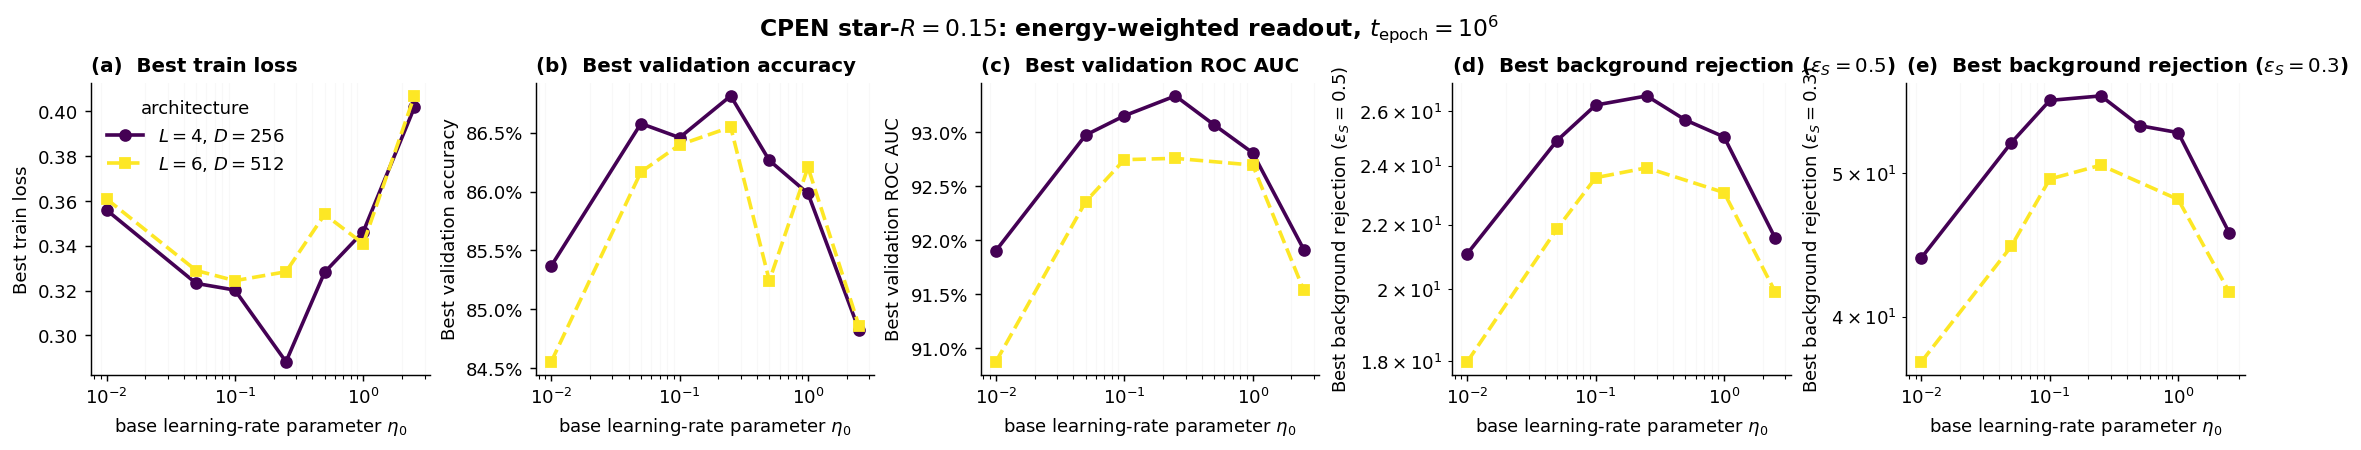

In [10]:
ENERGY_WEIGHT_CONFIG = {
    "model": "cpen",
    "optimizer": "adamw",
    "t_epoch": 1_000_000.0,
    "normalization": "energy-weights",
    "operators": "incidence",
    "operator_normalization": "gamma",
    "star_radius": 0.15,
    "scheduler": "cosine",
    "layer_norm": True,
    "residual_structure": "transformer-like",
}

fig, axes, energy_weight_summary = plot_eta_sweep(
    RESULT_ROOT,
    run_tag="norm-energy-weights",
    config=ENERGY_WEIGHT_CONFIG,
    title=r"CPEN star-$R=0.15$: energy-weighted readout, $t_{\rm epoch}=10^6$",
    savepath="figures/cpen_energy_weights_t1e6_eta_sweep.pdf",
)

energy_weight_summary[
    [
        "depth",
        "width",
        "eta_0",
        "epochs_completed",
        "train_loss",
        "val_acc",
        "val_roc_auc",
        "val_bg_rejection",
        "val_bg_rejection_0p3",
    ]
]